## **Read data and Imports**

In [1]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0],
        [tf.config.LogicalDeviceConfiguration(memory_limit=3000)]
    )

2026-05-12 20:49:42.574242: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-12 20:49:42.574334: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-12 20:49:42.575961: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-12 20:49:42.588518: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-12 20:49:43.758149: W tensorflow/compiler/tf2

In [2]:
import pandas as pd
import shap
from lime import lime_image
from skimage.segmentation import mark_boundaries
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from skrebate import ReliefF
import missingno as msno
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import os
import random
import cv2 as cv2
import sklearn
from sklearn.feature_selection import (
    mutual_info_regression,  # Information Gain
    chi2,                    # Chi-square Test
    f_classif,               # ANOVA (F-test)
    SelectKBest,             # Select top k features
    VarianceThreshold        # Variance Threshold
)
from sklearn.preprocessing import StandardScaler, MinMaxScaler

Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)


In [3]:
data = pd.read_csv("../../../Data/dataset_split/train/train.csv")

## **Preprocessing**

**Feature Engineering**

In [4]:
data2 = data.copy()

In [5]:
def drop_unwanted_columns(df):
    df = df.copy()

    cols_to_drop = [
        'nationality',
        'insuline',
        'focus',
        'Illuminaton',
        'image_field',
        'artifacts',
        'diabetes_time_y',
        'comorbidities',
        'camera',
        'quality',
        'other',
        'DR_SDRG'
    ]

    # drop only columns that actually exist
    # existing_cols = [col for col in cols_to_drop if col in df.columns]
    df = df.drop(columns=cols_to_drop)

    return df

In [6]:
data2 = drop_unwanted_columns(data2)

In [7]:
data2.head()

,image_id,patient_id,patient_age,patient_sex,exam_eye,diabetes,optic_disc,vessels,macula,DR_ICDR,...,scar,nevus,amd,vascular_occlusion,hypertensive_retinopathy,drusens,hemorrhage,retinal_detachment,myopic_fundus,increased_cup_disc
0,img00001,1,48.0,1,1,yes,1,1,1,0,...,0,0,0,0,0,0,0,0,0,1
1,img00002,1,48.0,1,2,yes,2,1,1,0,...,0,0,0,0,0,0,0,0,0,1
2,img00003,2,18.0,2,1,yes,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
3,img00004,2,18.0,2,2,yes,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,img00005,3,22.0,1,1,yes,2,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
def standardize_columns(df):
    df = df.copy()

    # exam_eye: make all splits use 0=left, 1=right
    df["exam_eye"] = pd.to_numeric(df["exam_eye"], errors="coerce")
    df["exam_eye"] = df["exam_eye"].map({1: 0, 2: 1})

    # binary medical features: 1->0, 2->1
    binary_12_cols = ["vessels", "macula", "patient_sex", "optic_disc"]
    for col in binary_12_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].map({1: 0, 2: 1})

    # diabetes: robust text handling
    if "diabetes" in df.columns:
        df["diabetes"] = (
            df["diabetes"].map({"yes": 1, "No": 0})
        )

    return df

In [9]:
data2 = standardize_columns(data2)

In [10]:
count = 1
for col in data2.columns:
    print(f"{count}. Unique Values for [ {col} ] is : ",data2[col].unique(),'\n')
    count+=1

1. Unique Values for [ image_id ] is :  ['img00001' 'img00002' 'img00003' ... 'img16262' 'img16265' 'img16266'] 

2. Unique Values for [ patient_id ] is :  [   1    2    3 ... 8520 8522 8524] 

3. Unique Values for [ patient_age ] is :  [48. 18. 22. 23. 14. 20. 28. 37. 21. 16. 24. 26. 19. 17. 13. 27. 39. 25.
 30. 15. 29. 57. 44. 38. 47. 42. 10. 59. 32. 66. 82. 87. 80. 41. 76. 71.
 73. 83. 45. 61. 55. 75. 81. 72. 64. 46. 74. 65. 31. 33. 53. 50. 51. 49.
 63. 62. 52. 70. 79. 60. 78. 54. 56. 77. 58. 85. 86. 84. 69. 11. 68. nan
  9. 91. 36. 90. 67. 88.  7. 35. 40. 43. 89. 34. 12.  8. 95. 97.  6. 93.
 94.  5. 92.] 

4. Unique Values for [ patient_sex ] is :  [0 1] 

5. Unique Values for [ exam_eye ] is :  [0 1] 

6. Unique Values for [ diabetes ] is :  [1 0] 

7. Unique Values for [ optic_disc ] is :  [0 1] 

8. Unique Values for [ vessels ] is :  [0 1] 

9. Unique Values for [ macula ] is :  [0 1] 

10. Unique Values for [ DR_ICDR ] is :  [0 1 2 4 3] 

11. Unique Values for [ diabetic_retin

In [11]:
def show_missing(data2):
    """
    Visualizes and reports missing values in a Pandas data2Frame.

    Parameters:
    - data2 (data2Frame): The input Pandas data2Frame to check for missing values.

    Returns:
    None

    This function performs the following tasks:
    1. Displays a missing data2 matrix plot to visualize the location of missing values in the data2Frame.
    2. Prints the percentage of missing values in each column with missing data2.
    3. Creates a bar plot to visualize the percentage of missing values in each column.

    Example usage:
    show_missing(data2)
    """
    
    # Visualize the percentage of missing data2 using a bar plot
    msno.matrix(data2)
    
    
    # Print the percentage of missing values in the columns with missing
    features_with_nan = [features for features in data2.columns if data2[features].isnull().sum()>=1]
    print(f'{len(features_with_nan)} columns with missing values detected:')

    for features in features_with_nan:
        print(features , np.round(data2[features].isnull().mean(),4) * 100 , '% missing values')

    
    # Create a bar plot to visualize missing values
    # Calculate the percentage of missing data2 in each column
    missing_percentage = data2.isnull().mean() * 100
    missing_percentage
    
    plt.figure(figsize=(10, 6))
    missing_percentage.plot(kind='bar', color='skyblue')
    plt.title('Percentage of Missing Values per Column')
    plt.xlabel('Columns')
    plt.ylabel('Percentage Missing')
    plt.xticks(rotation=90)
    plt.tight_layout()
    
    plt.show()

In [12]:
data2['patient_age'] = data2['patient_age'].fillna(data2['patient_age'].median())

0 columns with missing values detected:


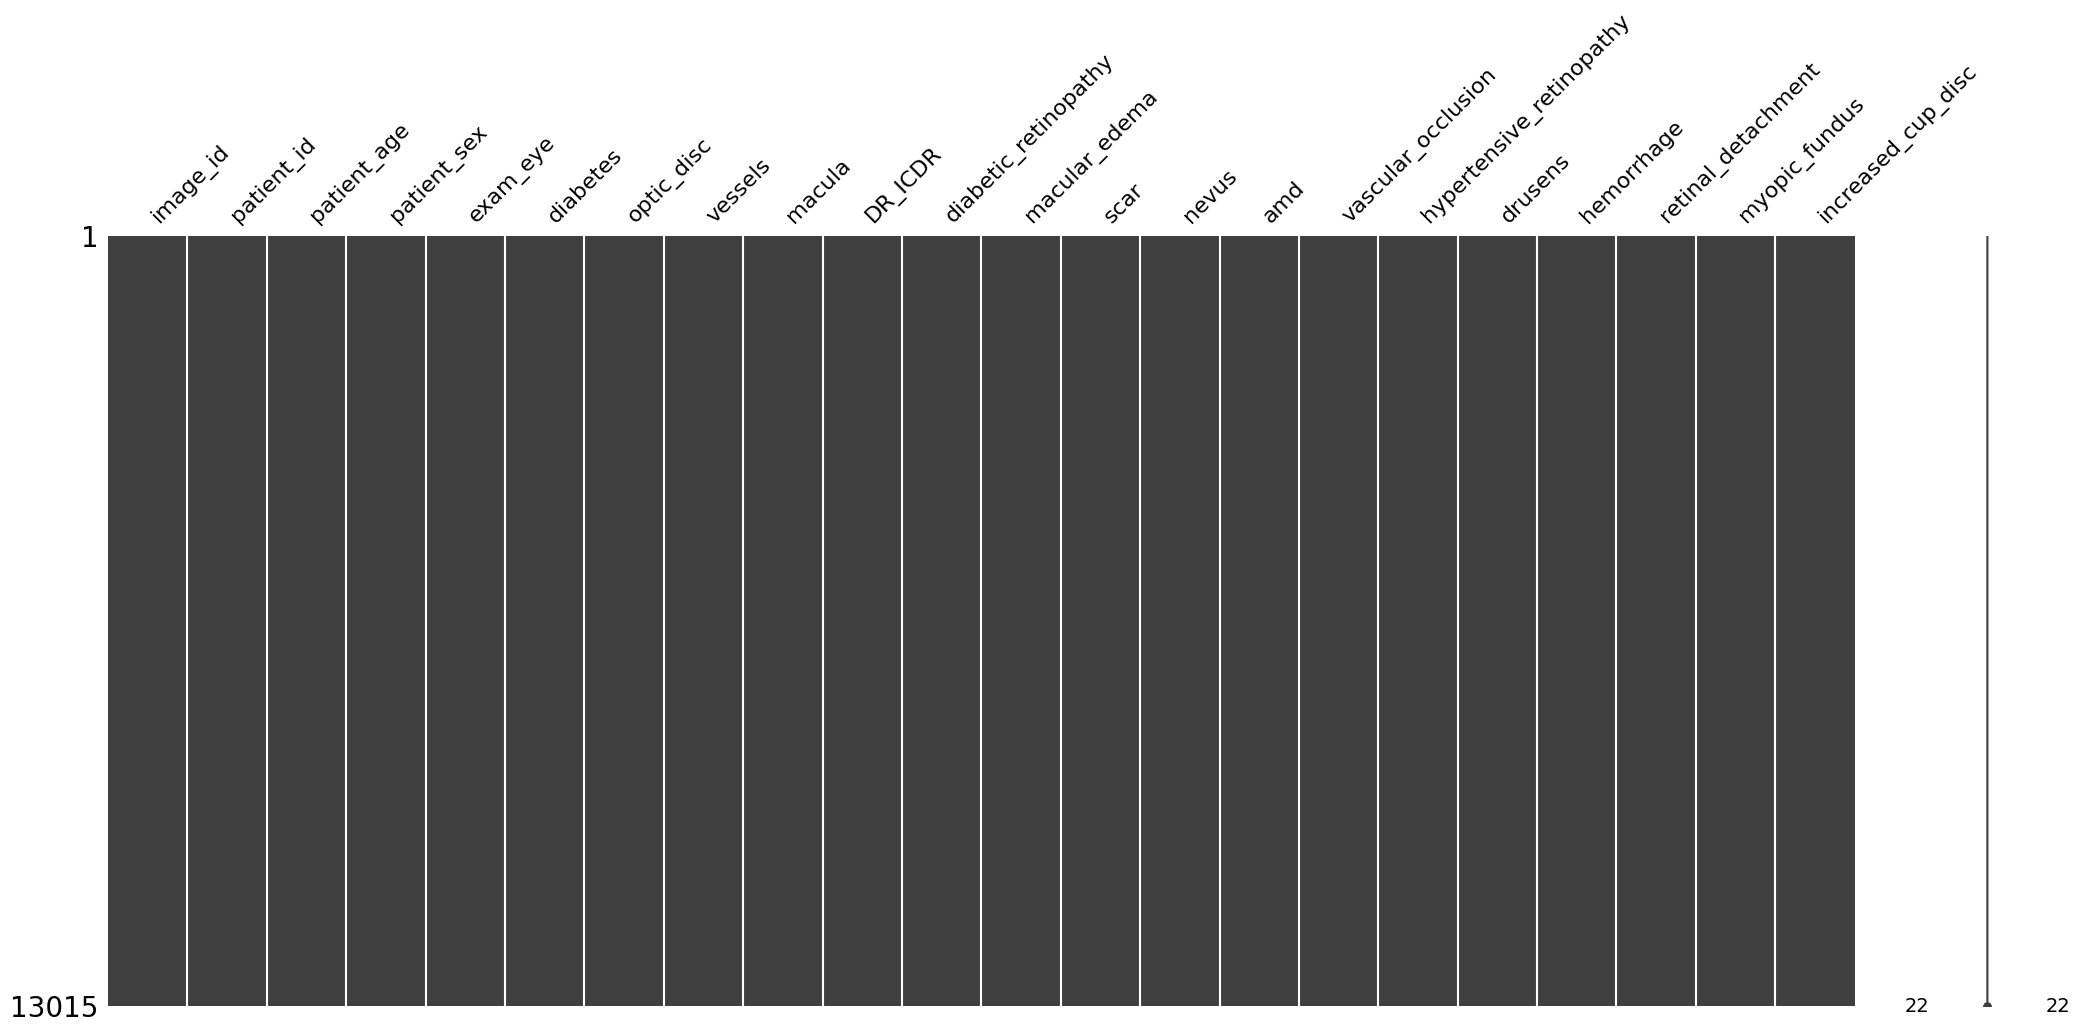

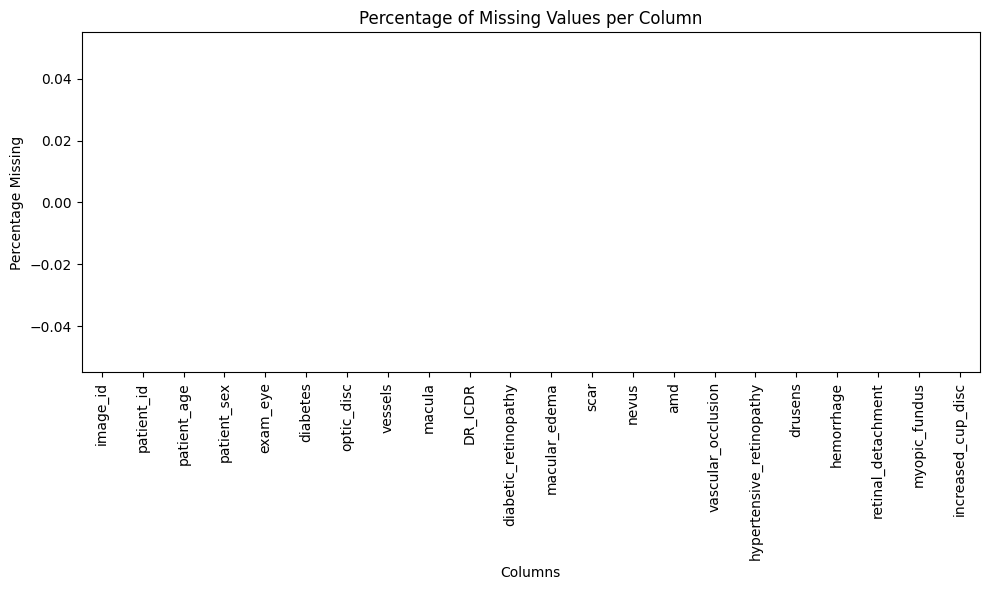

In [13]:
show_missing(data2)

In [14]:
data2_clean = data2.select_dtypes(include=['int64', 'float64'])
# data2_clean.drop(columns=['DR_ICDR'],inplace=True)

## **Model setup**

In [15]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score


In [16]:
# =========================================================
# 1) LOAD DATA
# =========================================================
train_data = data2.copy()
val_data  = pd.read_csv("../../../Data/dataset_split/val/val.csv")
test_data = pd.read_csv("../../../Data/dataset_split/test/test.csv")


In [17]:
IMAGE_DIR = "path_to_images"   # <-- change this
TARGET = "DR_ICDR"

CLASS_NAMES = [
    "Class 0",
    "Class 1",
    "Class 2",
    "Class 3",
    "Class 4"
]

tabular_features = [
    "patient_age",
    "patient_sex",
    "diabetes",
    "optic_disc",
    "vessels",
    "macula",
    "macular_edema",
    "drusens",
    "myopic_fundus"
]






In [18]:
val_data['patient_age'] = val_data['patient_age'].fillna(val_data['patient_age'].median())
test_data['patient_age'] = test_data['patient_age'].fillna(test_data['patient_age'].median())



In [19]:
val_data = drop_unwanted_columns(val_data)
test_data = drop_unwanted_columns(test_data)
val_data = standardize_columns(val_data)
test_data = standardize_columns(test_data)

In [20]:
test_data['optic_disc'] = test_data['optic_disc'].fillna(test_data['optic_disc'].median())

In [21]:
test_data.isna().sum()

image_id                    0
patient_id                  0
patient_age                 0
patient_sex                 0
exam_eye                    0
diabetes                    0
optic_disc                  0
vessels                     0
macula                      0
DR_ICDR                     0
diabetic_retinopathy        0
macular_edema               0
scar                        0
nevus                       0
amd                         0
vascular_occlusion          0
hypertensive_retinopathy    0
drusens                     0
hemorrhage                  0
retinal_detachment          0
myopic_fundus               0
increased_cup_disc          0
dtype: int64

In [22]:
# =========================================================
# 2) BASIC CLEANING
# =========================================================
def clean_dataframe(df, tabular_features, target):
    df = df.copy()

    for col in tabular_features + [target, "exam_eye"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df



train_data = clean_dataframe(train_data, tabular_features, TARGET)
val_data  = clean_dataframe(val_data, tabular_features, TARGET)
test_data = clean_dataframe(test_data, tabular_features, TARGET)



print("\nAfter cleaning:")
print("train_data:", train_data.shape)
print("val_data :", val_data.shape)
print("test_data :", test_data.shape)


After cleaning:
train_data: (13015, 22)
val_data : (1632, 22)
test_data : (1619, 22)


In [23]:
count = 1
for col in train_data.columns:
    print(f"{count}. Unique Values for [ {col} ] is : ",train_data[col].unique(),'\n')
    count+=1

1. Unique Values for [ image_id ] is :  ['img00001' 'img00002' 'img00003' ... 'img16262' 'img16265' 'img16266'] 

2. Unique Values for [ patient_id ] is :  [   1    2    3 ... 8520 8522 8524] 

3. Unique Values for [ patient_age ] is :  [48. 18. 22. 23. 14. 20. 28. 37. 21. 16. 24. 26. 19. 17. 13. 27. 39. 25.
 30. 15. 29. 57. 44. 38. 47. 42. 10. 59. 32. 66. 82. 87. 80. 41. 76. 71.
 73. 83. 45. 61. 55. 75. 81. 72. 64. 46. 74. 65. 31. 33. 53. 50. 51. 49.
 63. 62. 52. 70. 79. 60. 78. 54. 56. 77. 58. 85. 86. 84. 69. 11. 68.  9.
 91. 36. 90. 67. 88.  7. 35. 40. 43. 89. 34. 12.  8. 95. 97.  6. 93. 94.
  5. 92.] 

4. Unique Values for [ patient_sex ] is :  [0 1] 

5. Unique Values for [ exam_eye ] is :  [0 1] 

6. Unique Values for [ diabetes ] is :  [1 0] 

7. Unique Values for [ optic_disc ] is :  [0 1] 

8. Unique Values for [ vessels ] is :  [0 1] 

9. Unique Values for [ macula ] is :  [0 1] 

10. Unique Values for [ DR_ICDR ] is :  [0 1 2 4 3] 

11. Unique Values for [ diabetic_retinopat

In [24]:
# =========================================================
# 3) IMAGE PATHS
# =========================================================
# Make these EXACTLY match your real folders
TRAIN_IMAGE_DIR = "../../../Data/dataset_split/train/images_processed"
VAL_IMAGE_DIR   = "../../../Data/dataset_split/val/images_processed"
TEST_IMAGE_DIR  = "../../../Data/dataset_split/test/images_processed"

print("\nImage dir existence:")
print("TRAIN_IMAGE_DIR exists:", os.path.exists(TRAIN_IMAGE_DIR), TRAIN_IMAGE_DIR)
print("VAL_IMAGE_DIR exists  :", os.path.exists(VAL_IMAGE_DIR), VAL_IMAGE_DIR)
print("TEST_IMAGE_DIR exists :", os.path.exists(TEST_IMAGE_DIR), TEST_IMAGE_DIR)


def find_image_path(image_id, image_dir):
    image_id = str(image_id).strip()

    # try exact id first
    candidates = [
        image_id,
        image_id.lower(),
        image_id.upper()
    ]

    for candidate in candidates:
        for ext in [".png", ".jpg", ".jpeg", ".JPG", ".JPEG", ".PNG"]:
            path = os.path.join(image_dir, candidate + ext)
            if os.path.exists(path):
                return path

    return None


def attach_image_paths(df, image_dir, name="df"):
    df = df.copy()

    print(f"\n--- Attaching image paths for {name} ---")
    print("Input shape:", df.shape)
    print("Image dir exists:", os.path.exists(image_dir), image_dir)

    if "image_id" not in df.columns:
        raise ValueError(f"{name} does not contain 'image_id' column")

    print("Sample image_ids:", df["image_id"].astype(str).head(10).tolist())

    df["image_path"] = df["image_id"].astype(str).apply(lambda x: find_image_path(x, image_dir))

    found = df["image_path"].notna().sum()
    missing = df["image_path"].isna().sum()

    print("Images found:", found)
    print("Images missing:", missing)

    if found == 0:
        print("Warning: No images were matched. Check image_dir, file names, and extensions.")

    print("Sample resolved paths:", df["image_path"].dropna().head(5).tolist())

    df = df.dropna(subset=["image_path"]).reset_index(drop=True)

    print("Output shape after dropping missing image_path:", df.shape)
    return df


train_data2 = attach_image_paths(train_data, TRAIN_IMAGE_DIR, "train")
val_data2   = attach_image_paths(val_data, VAL_IMAGE_DIR, "val")
test_data2  = attach_image_paths(test_data, TEST_IMAGE_DIR, "test")


Image dir existence:
TRAIN_IMAGE_DIR exists: True ../../../Data/dataset_split/train/images_processed
VAL_IMAGE_DIR exists  : True ../../../Data/dataset_split/val/images_processed
TEST_IMAGE_DIR exists : True ../../../Data/dataset_split/test/images_processed

--- Attaching image paths for train ---
Input shape: (13015, 22)
Image dir exists: True ../../../Data/dataset_split/train/images_processed
Sample image_ids: ['img00001', 'img00002', 'img00003', 'img00004', 'img00005', 'img00006', 'img00007', 'img00008', 'img00009', 'img00010']
Images found: 13015
Images missing: 0
Sample resolved paths: ['../../../Data/dataset_split/train/images_processed/img00001.png', '../../../Data/dataset_split/train/images_processed/img00002.png', '../../../Data/dataset_split/train/images_processed/img00003.png', '../../../Data/dataset_split/train/images_processed/img00004.png', '../../../Data/dataset_split/train/images_processed/img00005.png']
Output shape after dropping missing image_path: (13015, 23)

--- 

In [25]:
# =========================================================
# 4) IMAGE-LEVEL -> PATIENT-LEVEL
# =========================================================
def build_patient_level_df(df, target, name="df"):
    df = df.copy()

    print(f"\n--- Building patient-level df for {name} ---")
    print("Input shape:", df.shape)

    expected_cols = [
        "patient_id", "patient_age", "patient_sex", "diabetes",
        "optic_disc", "vessels", "macula",
        "macular_edema", "drusens", "myopic_fundus",
        target, "left_image_path", "right_image_path"
    ]

    if df.empty:
        print("Warning: input dataframe is empty")
        return pd.DataFrame(columns=expected_cols)

    # -----------------------------------------
    # required columns check
    # -----------------------------------------
    required_cols = ["patient_id", "exam_eye", "image_path", target]
    missing_required = [c for c in required_cols if c not in df.columns]
    if missing_required:
        raise ValueError(f"{name}: Missing required columns: {missing_required}")

    # -----------------------------------------
    # normalize raw eye labels to strings
    # -----------------------------------------
    df["exam_eye"] = df["exam_eye"].astype(str).str.strip().str.lower()

    raw_unique = sorted(df["exam_eye"].dropna().unique().tolist())
    print("exam_eye raw unique:", raw_unique)

    # -----------------------------------------
    # detect coding scheme automatically
    # scheme A: 0=left, 1=right
    # scheme B: 1=left, 2=right
    # -----------------------------------------
    raw_set = set(raw_unique)

    if raw_set.issubset({"0", "1", "l", "r", "left", "right"}):
        eye_map = {
            "0": "left",
            "1": "right",
            "l": "left",
            "r": "right",
            "left": "left",
            "right": "right"
        }
        print("Detected eye coding: 0=left, 1=right")

    elif raw_set.issubset({"1", "2", "l", "r", "left", "right"}):
        eye_map = {
            "1": "left",
            "2": "right",
            "l": "left",
            "r": "right",
            "left": "left",
            "right": "right"
        }
        print("Detected eye coding: 1=left, 2=right")

    else:
        raise ValueError(
            f"{name}: Unsupported or mixed exam_eye values found: {raw_unique}"
        )

    df["exam_eye_norm"] = df["exam_eye"].map(eye_map)

    print("exam_eye normalized counts:\n", df["exam_eye_norm"].value_counts(dropna=False))

    # -----------------------------------------
    # safety check
    # -----------------------------------------
    if df["exam_eye_norm"].isna().any():
        bad_vals = df.loc[df["exam_eye_norm"].isna(), "exam_eye"].unique()
        raise ValueError(f"{name}: Unmapped exam_eye values found: {bad_vals}")

    # -----------------------------------------
    # split left and right
    # -----------------------------------------
    left_df = df[df["exam_eye_norm"] == "left"][["patient_id", "image_path"]].copy()
    right_df = df[df["exam_eye_norm"] == "right"][["patient_id", "image_path"]].copy()

    left_df = left_df.rename(columns={"image_path": "left_image_path"})
    right_df = right_df.rename(columns={"image_path": "right_image_path"})

    print("left_df shape :", left_df.shape)
    print("right_df shape:", right_df.shape)

    # -----------------------------------------
    # aggregate patient-level tabular data
    # -----------------------------------------
    agg_dict = {
        "patient_age": "first",
        "patient_sex": "first",
        "diabetes": "first",
        "optic_disc": "max",
        "vessels": "max",
        "macula": "max",
        "macular_edema": "max",
        "drusens": "max",
        "myopic_fundus": "max",
        target: "max"
    }

    # only keep columns that actually exist
    existing_agg_dict = {k: v for k, v in agg_dict.items() if k in df.columns}

    print("Aggregating columns:", list(existing_agg_dict.keys()))

    patient_tab = df.groupby("patient_id").agg(existing_agg_dict).reset_index()
    print("patient_tab shape:", patient_tab.shape)

    # -----------------------------------------
    # merge left/right eyes
    # -----------------------------------------
    patient_df = patient_tab.merge(left_df, on="patient_id", how="left")
    patient_df = patient_df.merge(right_df, on="patient_id", how="left")

    print("Missing left image :", patient_df["left_image_path"].isna().sum())
    print("Missing right image:", patient_df["right_image_path"].isna().sum())

    # -----------------------------------------
    # keep only complete pairs
    # -----------------------------------------
    patient_df = patient_df.dropna(
        subset=["left_image_path", "right_image_path", target]
    ).reset_index(drop=True)

    # -----------------------------------------
    # ensure all expected columns exist
    # -----------------------------------------
    for col in expected_cols:
        if col not in patient_df.columns:
            patient_df[col] = np.nan

    patient_df = patient_df[expected_cols]

    print("Final patient_df shape:", patient_df.shape)
    return patient_df


train_df = build_patient_level_df(train_data2, TARGET, "train")
val_df   = build_patient_level_df(val_data2, TARGET, "val")
test_df  = build_patient_level_df(test_data2, TARGET, "test")

print("\nFinal patient-level shapes:")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nFinal train_df columns:")
print(train_df.columns.tolist())


--- Building patient-level df for train ---
Input shape: (13015, 23)
exam_eye raw unique: ['0', '1']
Detected eye coding: 0=left, 1=right
exam_eye normalized counts:
 exam_eye_norm
left     6530
right    6485
Name: count, dtype: int64
left_df shape : (6530, 2)
right_df shape: (6485, 2)
Aggregating columns: ['patient_age', 'patient_sex', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'drusens', 'myopic_fundus', 'DR_ICDR']
patient_tab shape: (6819, 11)
Missing left image : 384
Missing right image: 424
Final patient_df shape: (6119, 13)

--- Building patient-level df for val ---
Input shape: (1632, 23)
exam_eye raw unique: ['0', '1']
Detected eye coding: 0=left, 1=right
exam_eye normalized counts:
 exam_eye_norm
left     817
right    815
Name: count, dtype: int64
left_df shape : (817, 2)
right_df shape: (815, 2)
Aggregating columns: ['patient_age', 'patient_sex', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'drusens', 'myopic_fundus', 'DR_ICDR']
patien

In [26]:
# =========================================================
# 4.5) PARTIAL OVERSAMPLING FOR DR_ICDR MINORITY CLASSES
# =========================================================
print("Before partial oversampling:")
print(train_df[TARGET].value_counts().sort_index())

MAJORITY_CLASS = 0
MINORITY_RATIO = 0.20

majority_df = train_df[train_df[TARGET] == MAJORITY_CLASS].copy()
target_minority_count = int(len(majority_df) * MINORITY_RATIO)

balanced_parts = [majority_df]

for cls in sorted(train_df[TARGET].dropna().astype(int).unique()):
    if cls == MAJORITY_CLASS:
        continue

    cls_df = train_df[train_df[TARGET] == cls].copy()

    if len(cls_df) == 0:
        continue

    sample_count = max(len(cls_df), target_minority_count)

    cls_oversampled = cls_df.sample(
        n=sample_count,
        replace=True,
        random_state=42 + int(cls)
    )

    balanced_parts.append(cls_oversampled)

train_df_balanced = pd.concat(
    balanced_parts,
    axis=0
)

train_df_balanced = train_df_balanced.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

print("\nAfter partial oversampling:")
print(train_df_balanced[TARGET].value_counts().sort_index())

print("\nFinal train_df_balanced shape:", train_df_balanced.shape)


Before partial oversampling:
DR_ICDR
0    5677
1      60
2     170
3      37
4     175
Name: count, dtype: int64

After partial oversampling:
DR_ICDR
0    5677
1    1135
2    1135
3    1135
4    1135
Name: count, dtype: int64

Final train_df_balanced shape: (10217, 13)


In [27]:
# =========================================================
# 5) TABULAR PREPROCESSING AFTER PARTIAL OVERSAMPLING
# =========================================================
if train_df_balanced.empty:
    raise ValueError("train_df_balanced is empty. Check patient-level construction and oversampling.")

tabular_features = [
    col for col in train_df.columns
    if col not in ["left_image_path", "right_image_path", TARGET]
]

print("\nTabular features:")
print(tabular_features)
print("Number of tabular features:", len(tabular_features))

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_train_tab = imputer.fit_transform(train_df_balanced[tabular_features])
X_val_tab = imputer.transform(val_df[tabular_features])
X_test_tab = imputer.transform(test_df[tabular_features])

X_train_tab = scaler.fit_transform(X_train_tab).astype("float32")
X_val_tab = scaler.transform(X_val_tab).astype("float32")
X_test_tab = scaler.transform(X_test_tab).astype("float32")

print("\nTabular arrays:")
print("X_train_tab:", X_train_tab.shape)
print("X_val_tab  :", X_val_tab.shape)
print("X_test_tab :", X_test_tab.shape)



Tabular features:
['patient_id', 'patient_age', 'patient_sex', 'diabetes', 'optic_disc', 'vessels', 'macula', 'macular_edema', 'drusens', 'myopic_fundus']
Number of tabular features: 10

Tabular arrays:
X_train_tab: (10217, 10)
X_val_tab  : (767, 10)
X_test_tab : (754, 10)


In [28]:





# =========================================================
# 5.5) LABELS AFTER PARTIAL OVERSAMPLING
# =========================================================
y_train = train_df_balanced[TARGET].values.astype("int32")
y_val = val_df[TARGET].values.astype("int32")
y_test = test_df[TARGET].values.astype("int32")

print("\nLabel arrays:")
print("y_train shape:", y_train.shape)
print("y_val shape  :", y_val.shape)
print("y_test shape :", y_test.shape)

print("\nBalanced y_train:")
print(pd.Series(y_train).value_counts().sort_index())







Label arrays:
y_train shape: (10217,)
y_val shape  : (767,)
y_test shape : (754,)

Balanced y_train:
0    5677
1    1135
2    1135
3    1135
4    1135
Name: count, dtype: int64


In [29]:
# =========================================================
# 6) IMAGE LOADER + DR_ICDR MINORITY AUGMENTATION
# =========================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 8

minority_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.02),
    tf.keras.layers.RandomZoom(0.04),
    tf.keras.layers.RandomContrast(0.08),
    tf.keras.layers.RandomBrightness(0.10),
    tf.keras.layers.GaussianNoise(0.01),
], name="dr_icdr_minority_augmentation")


def load_image(path):
    img = tf.io.read_file(path)

    img = tf.image.decode_image(
        img,
        channels=3,
        expand_animations=False
    )

    img.set_shape([None, None, 3])

    img = tf.image.resize(
        img,
        IMG_SIZE
    )

    img = tf.cast(img, tf.float32) / 255.0

    return img


def augment_single_image(img):
    img = tf.expand_dims(img, axis=0)
    img = minority_augmentation(img, training=True)
    img = tf.squeeze(img, axis=0)
    img = tf.clip_by_value(img, 0.0, 1.0)

    return img


def make_dataset(
    left_paths,
    right_paths,
    tabular_data,
    labels,
    training=True,
    augment_minority=False
):
    ds = tf.data.Dataset.from_tensor_slices(
        (
            left_paths,
            right_paths,
            tabular_data,
            labels
        )
    )

    def _map_fn(lp, rp, tab, label):
        left_img = load_image(lp)
        right_img = load_image(rp)

        label_int = tf.cast(label, tf.int32)

        if training and augment_minority:
            is_minority = tf.greater(
                label_int,
                0
            )

            left_img = tf.cond(
                is_minority,
                lambda: augment_single_image(left_img),
                lambda: left_img
            )

            right_img = tf.cond(
                is_minority,
                lambda: augment_single_image(right_img),
                lambda: right_img
            )

        inputs = {
            "left_image_input": left_img,
            "right_image_input": right_img,
            "tabular_input": tf.cast(tab, tf.float32)
        }

        return inputs, label_int

    ds = ds.map(
        _map_fn,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if training:
        ds = ds.shuffle(
            1000,
            reshuffle_each_iteration=True
        )

    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = make_dataset(
    train_df_balanced["left_image_path"].values,
    train_df_balanced["right_image_path"].values,
    X_train_tab,
    y_train,
    training=True,
    augment_minority=True
)

val_ds = make_dataset(
    val_df["left_image_path"].values,
    val_df["right_image_path"].values,
    X_val_tab,
    y_val,
    training=False,
    augment_minority=False
)

test_ds = make_dataset(
    test_df["left_image_path"].values,
    test_df["right_image_path"].values,
    X_test_tab,
    y_test,
    training=False,
    augment_minority=False
)


# =========================================================
# CLASS WEIGHTS
# =========================================================
class_weight = {
    0: 0.3,
    1: 5.0,
    2: 4.0,
    3: 8.0,
    4: 5.0
}

print("\nClass weights:")
print(class_weight)


2026-05-12 20:49:49.803740: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 20:49:49.803845: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 20:49:49.803882: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 20:49:50.715635: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:887] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-05-12 20:49:50.715661: I tensorflow/core/common_runtime/gpu/gpu


Class weights:
{0: 0.3, 1: 5.0, 2: 4.0, 3: 8.0, 4: 5.0}


## **Model**

In [30]:
import os
import json
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models
from sklearn.metrics import (
    roc_auc_score,
    f1_score,
    classification_report,
    confusion_matrix,
    recall_score,
    precision_score,
    accuracy_score,
    balanced_accuracy_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize


tf.keras.backend.clear_session()

np.random.seed(42)
tf.random.set_seed(42)


# =========================================================
# CAPSNET SETUP
# =========================================================
IMAGE_SIZE = 224
NUM_CLASSES = 5
CLASS_NAMES = [
    "Class 0",
    "Class 1",
    "Class 2",
    "Class 3",
    "Class 4"
]

CAPSULE_DIM = 8
PRIMARY_CAPSULES = 8
CLASS_CAPSULE_DIM = 16
TABULAR_CAPSULES = 8
ROUTING_ITERS = 2

IMAGE_CAPSULES_PER_EYE = 7 * 7 * PRIMARY_CAPSULES
FUSED_CAPSULES = (IMAGE_CAPSULES_PER_EYE * 2) + TABULAR_CAPSULES


# =========================================================
# TRAINING SETUP
# =========================================================
STAGE1_EPOCHS = 25
STAGE2_EXTRA_EPOCHS = 25

STAGE1_LR = 1e-4
STAGE2_LR = 1e-5

WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.00


# =========================================================
# SAVE DIRECTORY
# =========================================================
SAVE_DIR = "Model3_Paper1_capsnet_DR_ICDR_5class_tabular_injected_improved"
os.makedirs(SAVE_DIR, exist_ok=True)


# =========================================================
# JSON HELPER
# =========================================================
def make_json_serializable(history_dict):
    clean_history = {}

    for key, values in history_dict.items():
        clean_history[key] = [float(v) for v in values]

    return clean_history


In [31]:
# =========================================================
# CAPSULE FUNCTIONS
# =========================================================
@tf.keras.utils.register_keras_serializable()
def squash_function(x):
    squared_norm = tf.reduce_sum(tf.square(x), axis=-1, keepdims=True)
    scale = squared_norm / (1.0 + squared_norm)
    return scale * x / tf.sqrt(squared_norm + 1e-7)


@tf.keras.utils.register_keras_serializable()
def dynamic_routing_function(u_hat):
    batch_size = tf.shape(u_hat)[0]

    b = tf.zeros(
        shape=(
            batch_size,
            FUSED_CAPSULES,
            NUM_CLASSES
        )
    )

    for i in range(ROUTING_ITERS):
        c = tf.nn.softmax(b, axis=2)

        s = tf.reduce_sum(
            tf.expand_dims(c, axis=-1) * u_hat,
            axis=1
        )

        v = squash_function(s)

        if i < ROUTING_ITERS - 1:
            agreement = tf.reduce_sum(
                u_hat * tf.expand_dims(v, axis=1),
                axis=-1
            )

            b = b + agreement

    return v


@tf.keras.utils.register_keras_serializable()
def capsule_length_function(x):
    return tf.sqrt(
        tf.reduce_sum(tf.square(x), axis=-1) + 1e-7
    )


@tf.keras.utils.register_keras_serializable()
def class_probability_function(x):
    return tf.nn.softmax(x, axis=-1)


CUSTOM_OBJECTS = {
    "squash_function": squash_function,
    "dynamic_routing_function": dynamic_routing_function,
    "capsule_length_function": capsule_length_function,
    "class_probability_function": class_probability_function
}


In [32]:
# =========================================================
# CONV BLOCK
# =========================================================
def conv_block(x, filters, kernel_size=3, strides=1, name=None):
    x = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        padding="same",
        use_bias=False,
        name=None if name is None else name + "_conv"
    )(x)

    x = layers.BatchNormalization(
        name=None if name is None else name + "_bn"
    )(x)

    x = layers.Activation(
        "relu",
        name=None if name is None else name + "_relu"
    )(x)

    return x


# =========================================================
# IMAGE CAPSULE BRANCH
# =========================================================
def create_image_capsule_branch():
    image_input = layers.Input(
        shape=(224, 224, 3),
        name="image_input"
    )

    x = conv_block(image_input, 32, kernel_size=5, strides=2, name="conv_block_1")
    x = conv_block(x, 64, kernel_size=3, strides=2, name="conv_block_2")
    x = conv_block(x, 96, kernel_size=3, strides=2, name="conv_block_3")
    x = conv_block(x, 128, kernel_size=3, strides=2, name="conv_block_4")

    x = layers.Conv2D(
        PRIMARY_CAPSULES * CAPSULE_DIM,
        kernel_size=3,
        strides=2,
        padding="same",
        activation="relu",
        name="primary_capsule_conv"
    )(x)

    x = layers.Reshape(
        (IMAGE_CAPSULES_PER_EYE, CAPSULE_DIM),
        name="primary_capsule_reshape"
    )(x)

    x = layers.Lambda(
        squash_function,
        output_shape=(IMAGE_CAPSULES_PER_EYE, CAPSULE_DIM),
        name="primary_capsules"
    )(x)

    branch = models.Model(
        inputs=image_input,
        outputs=x,
        name="shared_image_capsule_branch"
    )

    return branch


# =========================================================
# BUILD MODEL
# =========================================================
def build_model(tabular_dim):
    left_input = layers.Input(shape=(224, 224, 3), name="left_image_input")
    right_input = layers.Input(shape=(224, 224, 3), name="right_image_input")
    tabular_input = layers.Input(shape=(tabular_dim,), name="tabular_input")

    image_branch = create_image_capsule_branch()

    left_capsules = image_branch(left_input)
    right_capsules = image_branch(right_input)

    image_capsules = layers.Concatenate(
        axis=1,
        name="left_right_image_capsules"
    )([left_capsules, right_capsules])

    tab = layers.Dense(
        64,
        activation="relu",
        name="tab_dense_1"
    )(tabular_input)

    tab = layers.BatchNormalization(
        name="tab_batch_norm"
    )(tab)

    tab = layers.Dropout(
        0.40,
        name="tab_dropout"
    )(tab)

    tab = layers.Dense(
        TABULAR_CAPSULES * CAPSULE_DIM,
        activation="relu",
        name="tab_capsule_dense"
    )(tab)

    tab_capsules = layers.Reshape(
        (TABULAR_CAPSULES, CAPSULE_DIM),
        name="tab_capsule_reshape"
    )(tab)

    tab_capsules = layers.Lambda(
        squash_function,
        output_shape=(TABULAR_CAPSULES, CAPSULE_DIM),
        name="tabular_capsules"
    )(tab_capsules)

    fused_capsules = layers.Concatenate(
        axis=1,
        name="image_tabular_capsules_before_routing"
    )([image_capsules, tab_capsules])

    u_hat = layers.Dense(
        NUM_CLASSES * CLASS_CAPSULE_DIM,
        activation=None,
        name="capsule_prediction_vectors"
    )(fused_capsules)

    u_hat = layers.Reshape(
        (FUSED_CAPSULES, NUM_CLASSES, CLASS_CAPSULE_DIM),
        name="capsule_prediction_reshape"
    )(u_hat)

    class_capsules = layers.Lambda(
        dynamic_routing_function,
        output_shape=(NUM_CLASSES, CLASS_CAPSULE_DIM),
        name="class_capsules_dynamic_routing"
    )(u_hat)

    class_lengths = layers.Lambda(
        capsule_length_function,
        output_shape=(NUM_CLASSES,),
        name="class_capsule_lengths"
    )(class_capsules)

    output = layers.Lambda(
        class_probability_function,
        output_shape=(NUM_CLASSES,),
        name="output"
    )(class_lengths)

    model = models.Model(
        inputs={
            "left_image_input": left_input,
            "right_image_input": right_input,
            "tabular_input": tabular_input
        },
        outputs=output,
        name="multimodal_capsnet_tabular_injected"
    )

    return model


# =========================================================
# CREATE MODEL
# =========================================================
tf.keras.backend.clear_session()

model = build_model(
    tabular_dim=X_train_tab.shape[1]
)

model.summary()


Model: "multimodal_capsnet_tabular_injected"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 tabular_input (InputLayer)  [(None, 10)]                 0         []                            
                                                                                                  
 tab_dense_1 (Dense)         (None, 64)                   704       ['tabular_input[0][0]']       
                                                                                                  
 tab_batch_norm (BatchNorma  (None, 64)                   256       ['tab_dense_1[0][0]']         
 lization)                                                                                        
                                                                                                  
 tab_dropout (Dropout)       (None, 64)                   0     

In [33]:
# =========================================================
# SAVE MODEL CONFIGURATION
# =========================================================
model_config = {
    "model_name": "multimodal_capsnet_tabular_injected_improved",
    "task": "DR_ICDR_5_class_grading",
    "input_image_size": IMAGE_SIZE,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "capsule_dim": CAPSULE_DIM,
    "primary_capsules": PRIMARY_CAPSULES,
    "class_capsule_dim": CLASS_CAPSULE_DIM,
    "tabular_capsules": TABULAR_CAPSULES,
    "routing_iters": ROUTING_ITERS,
    "image_capsules_per_eye": IMAGE_CAPSULES_PER_EYE,
    "fused_capsules": FUSED_CAPSULES,
    "fusion_method": "tabular_embedding_converted_to_capsules_and_concatenated_before_dynamic_routing",
    "extra_image_preprocessing_inside_model": False,
    "tabular_dropout": 0.40,
    "loss": "SparseCategoricalCrossentropy",
    "weight_decay": WEIGHT_DECAY,
    "optimizer": "AdamW",
    "stage1_lr": STAGE1_LR,
    "stage2_lr": STAGE2_LR,
    "stage1_epochs": STAGE1_EPOCHS,
    "stage2_extra_epochs": STAGE2_EXTRA_EPOCHS
}

with open(os.path.join(SAVE_DIR, "model_config.json"), "w") as f:
    json.dump(model_config, f, indent=4)

print("Model configuration saved.")


Model configuration saved.


In [34]:
# =========================================================
# CLASS WEIGHTS
# =========================================================
classes = np.unique(y_train.astype(int))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.astype(int)
)

class_weight = {
    int(k): float(v)
    for k, v in zip(classes, weights)
}

print("Class weights:", class_weight)

Class weights: {0: 0.35994363220010567, 1: 1.800352422907489, 2: 1.800352422907489, 3: 1.800352422907489, 4: 1.800352422907489}


In [35]:
tf.keras.backend.clear_session()

In [38]:
def sparse_categorical_focal_loss(gamma=2.0, alpha=None):
    alpha = tf.constant(alpha, dtype=tf.float32)

    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.reshape(y_true, [-1])

        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        y_true_one_hot = tf.one_hot(y_true, depth=tf.shape(y_pred)[-1])

        ce = -y_true_one_hot * tf.math.log(y_pred)
        focal = tf.pow(1.0 - y_pred, gamma) * ce
        focal = focal * alpha

        return tf.reduce_sum(focal, axis=-1)

    return loss

In [39]:

# =========================================================
# COMPILE STAGE 1
# =========================================================
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=STAGE1_LR,
        weight_decay=WEIGHT_DECAY
    ),
    loss=sparse_categorical_focal_loss(
        gamma=2.0,
        alpha=[0.25, 4.0, 4.0, 6.0, 4.5]
    ),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)

# =========================================================
# CALLBACKS STAGE 1
# =========================================================
callbacks_stage1 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, "best_stage1_model.keras"),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, "last_stage1_model.keras"),
        save_best_only=False,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]


# =========================================================
# TRAIN STAGE 1
# =========================================================
history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=STAGE1_EPOCHS,
    callbacks=callbacks_stage1,
    class_weight={
        0: 0.3,
        1: 5.0,
        2: 4.0,
        3: 8.0,
        4: 5.0
    },
    verbose=1
)


# =========================================================
# SAVE HISTORY STAGE 1
# =========================================================
history_stage1_clean = make_json_serializable(
    history_stage1.history
)

with open(os.path.join(SAVE_DIR, "history_stage1.json"), "w") as f:
    json.dump(history_stage1_clean, f, indent=4)


# =========================================================
# SAVE RESUME INFO STAGE 1
# =========================================================
completed_epochs_stage1 = len(history_stage1.history["loss"])

resume_info_stage1 = {
    "completed_epochs": completed_epochs_stage1,
    "best_model_path": os.path.join(SAVE_DIR, "best_stage1_model.keras"),
    "last_model_path": os.path.join(SAVE_DIR, "last_stage1_model.keras"),
    "next_phase": "stage2_continue_training"
}

with open(os.path.join(SAVE_DIR, "resume_info_stage1.json"), "w") as f:
    json.dump(resume_info_stage1, f, indent=4)


# =========================================================
# SAVE FINAL STAGE 1 MODEL
# =========================================================
model.save(
    os.path.join(SAVE_DIR, "final_stage1_model.keras")
)

print("Stage 1 training finished.")
print("Completed epochs:", completed_epochs_stage1)


Epoch 1/25


2026-05-12 20:52:21.383191: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2026-05-12 20:52:21.492631: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-12 20:52:21.617126: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-05-12 20:52:23.661873: I external/local_xla/xla/service/service.cc:168] XLA service 0x7a1c8e9f37d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-05-12 20:52:23.661926: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce GTX 1650, Compute Capability 7.5
2026-05-12 20:52:23.668699: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778608343.768772   21663 device_compiler.

1278/1278 [==============================] - ETA: 0s - loss: 10.0920 - accuracy: 0.1116
Epoch 1: val_accuracy improved from -inf to 0.00522, saving model to Model3_Paper1_capsnet_DR_ICDR_5class_tabular_injected_improved/best_stage1_model.keras

Epoch 1: saving model to Model3_Paper1_capsnet_DR_ICDR_5class_tabular_injected_improved/last_stage1_model.keras
1278/1278 [==============================] - 81s 55ms/step - loss: 10.0920 - accuracy: 0.1116 - val_loss: 0.5138 - val_accuracy: 0.0052 - lr: 1.0000e-04
Epoch 2/25
1277/1278 [============================>.] - ETA: 0s - loss: 9.5116 - accuracy: 0.1109
Epoch 2: val_accuracy did not improve from 0.00522

Epoch 2: saving model to Model3_Paper1_capsnet_DR_ICDR_5class_tabular_injected_improved/last_stage1_model.keras
1278/1278 [==============================] - 73s 54ms/step - loss: 9.5148 - accuracy: 0.1110 - val_loss: 0.5070 - val_accuracy: 0.0052 - lr: 1.0000e-04
Epoch 3/25
1277/1278 [============================>.] - ETA: 0s - loss: 9.25

In [ ]:
# =========================================================
# LOAD BEST STAGE 1 MODEL
# =========================================================
best_stage1_path = os.path.join(
    SAVE_DIR,
    "best_stage1_model.keras"
)

model_stage2 = tf.keras.models.load_model(
    best_stage1_path,
    custom_objects=CUSTOM_OBJECTS,
    safe_mode=False
)

print("Loaded best stage 1 model:")
print(best_stage1_path)


# =========================================================
# LOAD STAGE 1 RESUME INFO
# =========================================================
stage1_info_path = os.path.join(
    SAVE_DIR,
    "resume_info_stage1.json"
)

if os.path.exists(stage1_info_path):
    with open(stage1_info_path, "r") as f:
        stage1_info = json.load(f)

    start_epoch = stage1_info["completed_epochs"]
else:
    start_epoch = 0

print("Stage 1 completed epochs:", start_epoch)


# =========================================================
# COMPILE STAGE 2
# =========================================================
model.compile(
    optimizer=tf.keras.optimizers.AdamW(
        learning_rate=STAGE1_LR,
        weight_decay=WEIGHT_DECAY
    ),
    loss=sparse_categorical_focal_loss(
        gamma=2.0,
        alpha=[0.25, 4.0, 4.0, 6.0, 4.5]
    ),
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")
    ]
)


# =========================================================
# CLASS WEIGHTS
# =========================================================
classes = np.unique(y_train.astype(int))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train.astype(int)
)

class_weight = {
    int(k): float(v)
    for k, v in zip(classes, weights)
}

print("Class weights:", class_weight)


# =========================================================
# CALLBACKS STAGE 2
# =========================================================
callbacks_stage2 = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, "best_stage2_model.keras"),
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath=os.path.join(SAVE_DIR, "last_stage2_model.keras"),
        save_best_only=False,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=8,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.3,
        patience=3,
        min_delta=0.001,
        min_lr=1e-7,
        verbose=1
    )
]


# =========================================================
# TRAIN STAGE 2
# =========================================================
total_epochs = start_epoch + STAGE2_EXTRA_EPOCHS

print("Stage 2 starts from epoch:", start_epoch)
print("Stage 2 will run until epoch:", total_epochs)

history_stage2 = model_stage2.fit(
    train_ds,
    validation_data=val_ds,
    initial_epoch=start_epoch,
    epochs=total_epochs,
    callbacks=callbacks_stage2,
    class_weight=class_weight,
    verbose=1
)


# =========================================================
# SAVE HISTORY STAGE 2
# =========================================================
history_stage2_clean = make_json_serializable(
    history_stage2.history
)

with open(os.path.join(SAVE_DIR, "history_stage2.json"), "w") as f:
    json.dump(history_stage2_clean, f, indent=4)


# =========================================================
# SAVE RESUME INFO STAGE 2
# =========================================================
completed_epochs_stage2 = start_epoch + len(
    history_stage2.history["loss"]
)

resume_info_stage2 = {
    "stage1_completed_epochs": start_epoch,
    "stage2_completed_epochs_total": completed_epochs_stage2,
    "best_model_path": os.path.join(SAVE_DIR, "best_stage2_model.keras"),
    "last_model_path": os.path.join(SAVE_DIR, "last_stage2_model.keras"),
    "final_model_path": os.path.join(SAVE_DIR, "best_final_stage2_model.keras")
}

with open(os.path.join(SAVE_DIR, "resume_info_stage2.json"), "w") as f:
    json.dump(resume_info_stage2, f, indent=4)


# =========================================================
# SAVE FINAL STAGE 2 MODEL
# =========================================================
model_stage2.save(
    os.path.join(SAVE_DIR, "final_stage2_model.keras")
)

best_stage2_model = tf.keras.models.load_model(
    os.path.join(SAVE_DIR, "best_stage2_model.keras"),
    custom_objects=CUSTOM_OBJECTS,
    safe_mode=False
)

best_stage2_model.save(
    os.path.join(SAVE_DIR, "best_final_stage2_model.keras")
)

model = best_stage2_model

print("Stage 2 training finished.")
print("Completed total epochs:", completed_epochs_stage2)
print("Best final model saved.")


Loaded best stage 1 model:
Model3_Paper1_capsnet_DR_ICDR_5class_tabular_injected_improved/best_stage1_model.keras
Stage 1 completed epochs: 8
Class weights: {0: 0.35994363220010567, 1: 1.800352422907489, 2: 1.800352422907489, 3: 1.800352422907489, 4: 1.800352422907489}
Stage 2 starts from epoch: 8
Stage 2 will run until epoch: 33
Epoch 9/33
1277/1278 [============================>.] - ETA: 0s - loss: 1.3727 - accuracy: 0.6666
Epoch 9: val_accuracy improved from -inf to 0.94133, saving model to Model3_Paper1_capsnet_DR_ICDR_5class_tabular_injected_improved/best_stage2_model.keras

Epoch 9: saving model to Model3_Paper1_capsnet_DR_ICDR_5class_tabular_injected_improved/last_stage2_model.keras
1278/1278 [==============================] - 76s 54ms/step - loss: 1.3726 - accuracy: 0.6666 - val_loss: 0.9845 - val_accuracy: 0.9413 - lr: 1.0000e-05
Epoch 10/33
1277/1278 [============================>.] - ETA: 0s - loss: 1.3721 - accuracy: 0.6660
Epoch 10: val_accuracy did not improve from 0.9413

In [ ]:
# =========================================================
# LOAD BEST FINAL MODEL
# =========================================================
best_final_path = os.path.join(SAVE_DIR, "best_final_stage2_model.keras")

if not os.path.exists(best_final_path):
    best_final_path = os.path.join(SAVE_DIR, "best_stage2_model.keras")

if not os.path.exists(best_final_path):
    best_final_path = os.path.join(SAVE_DIR, "best_stage1_model.keras")

model = tf.keras.models.load_model(
    best_final_path,
    custom_objects=CUSTOM_OBJECTS,
    safe_mode=False
)

print("Loaded model:", best_final_path)
model.summary()


Loaded model: Model3_Paper1_capsnet_DR_ICDR_5class_tabular_injected_improved/best_final_stage2_model.keras
Model: "multimodal_capsnet_tabular_injected"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 tabular_input (InputLayer)  [(None, 10)]                 0         []                            
                                                                                                  
 tab_dense_1 (Dense)         (None, 64)                   704       ['tabular_input[0][0]']       
                                                                                                  
 tab_batch_norm (BatchNorma  (None, 64)                   256       ['tab_dense_1[0][0]']         
 lization)                                                                                        
                                                        

In [ ]:
# =========================================================
# TEST EVALUATION
# =========================================================
y_test_array = np.asarray(y_test).astype(int)

pred_probs = model.predict(test_ds)
preds = np.argmax(pred_probs, axis=1)

print(f"Accuracy: {accuracy_score(y_test_array, preds):.4f}")
print(f"Balanced Accuracy: {balanced_accuracy_score(y_test_array, preds):.4f}")
print(f"Macro F1-score: {f1_score(y_test_array, preds, average='macro'):.4f}")
print(f"Weighted F1-score: {f1_score(y_test_array, preds, average='weighted'):.4f}")
print(f"Macro Recall: {recall_score(y_test_array, preds, average='macro', zero_division=0):.4f}")
print(f"Macro Precision: {precision_score(y_test_array, preds, average='macro', zero_division=0):.4f}")

try:
    test_auc = roc_auc_score(
        y_test_array,
        pred_probs,
        multi_class="ovr",
        average="macro"
    )
    print(f"Macro ROC-AUC OVR: {test_auc:.4f}")
except ValueError as e:
    print("Macro ROC-AUC OVR could not be computed:", e)

print("\nClassification Report:")
print(
    classification_report(
        y_test_array,
        preds,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0
    )
)

print("Confusion Matrix:")
print(confusion_matrix(y_test_array, preds, labels=list(range(NUM_CLASSES))))


95/95 [==============================] - 2s 19ms/step
Accuracy: 0.9125
Balanced Accuracy: 0.2000
Macro F1-score: 0.1908
Weighted F1-score: 0.8707
Macro Recall: 0.2000
Macro Precision: 0.1825
Macro ROC-AUC OVR: 0.6775

Classification Report:
              precision    recall  f1-score   support

     Class 0     0.9125    1.0000    0.9542       688
     Class 1     0.0000    0.0000    0.0000         9
     Class 2     0.0000    0.0000    0.0000        31
     Class 3     0.0000    0.0000    0.0000         3
     Class 4     0.0000    0.0000    0.0000        23

    accuracy                         0.9125       754
   macro avg     0.1825    0.2000    0.1908       754
weighted avg     0.8326    0.9125    0.8707       754

Confusion Matrix:
[[688   0   0   0   0]
 [  9   0   0   0   0]
 [ 31   0   0   0   0]
 [  3   0   0   0   0]
 [ 23   0   0   0   0]]


## **Validation Prediction Lab**

In [ ]:
# =========================================================
# VALIDATION PREDICTION ANALYSIS
# =========================================================
y_val_array = np.asarray(y_val).astype(int)

val_probs = model.predict(val_ds)
val_preds = np.argmax(val_probs, axis=1)

validation_results = {
    "accuracy": float(accuracy_score(y_val_array, val_preds)),
    "balanced_accuracy": float(balanced_accuracy_score(y_val_array, val_preds)),
    "macro_f1": float(f1_score(y_val_array, val_preds, average="macro")),
    "weighted_f1": float(f1_score(y_val_array, val_preds, average="weighted")),
    "macro_recall": float(recall_score(y_val_array, val_preds, average="macro", zero_division=0)),
    "macro_precision": float(precision_score(y_val_array, val_preds, average="macro", zero_division=0))
}

try:
    validation_results["macro_roc_auc_ovr"] = float(
        roc_auc_score(
            y_val_array,
            val_probs,
            multi_class="ovr",
            average="macro"
        )
    )
except ValueError as e:
    validation_results["macro_roc_auc_ovr"] = str(e)

validation_results_df = pd.DataFrame([validation_results])

validation_results_df.to_csv(
    os.path.join(SAVE_DIR, "validation_prediction_results.csv"),
    index=False
)

with open(os.path.join(SAVE_DIR, "validation_prediction_results.json"), "w") as f:
    json.dump(validation_results, f, indent=4)

print("Validation prediction results saved.")
validation_results_df


96/96 [==============================] - 1s 14ms/step
Validation prediction results saved.


,accuracy,balanced_accuracy,macro_f1,weighted_f1,macro_recall,macro_precision,macro_roc_auc_ovr
0,0.94133,0.2,0.193956,0.912881,0.2,0.188266,0.701115


In [ ]:
# =========================================================
# TRAIN / VALIDATION / TEST RESULTS
# =========================================================
train_results = model.evaluate(train_ds, verbose=1)
val_results = model.evaluate(val_ds, verbose=1)
test_results = model.evaluate(test_ds, verbose=1)

metrics_names = model.metrics_names

results_df = pd.DataFrame(
    [train_results, val_results, test_results],
    columns=metrics_names,
    index=["Train", "Validation", "Test"]
)

results_df

95/95 [==============================] - 1s 15ms/step - loss: 1.0120 - accuracy: 0.9125


,loss,accuracy
Train,1.174416,0.666536
Validation,0.984485,0.941330
Test,1.011994,0.912467


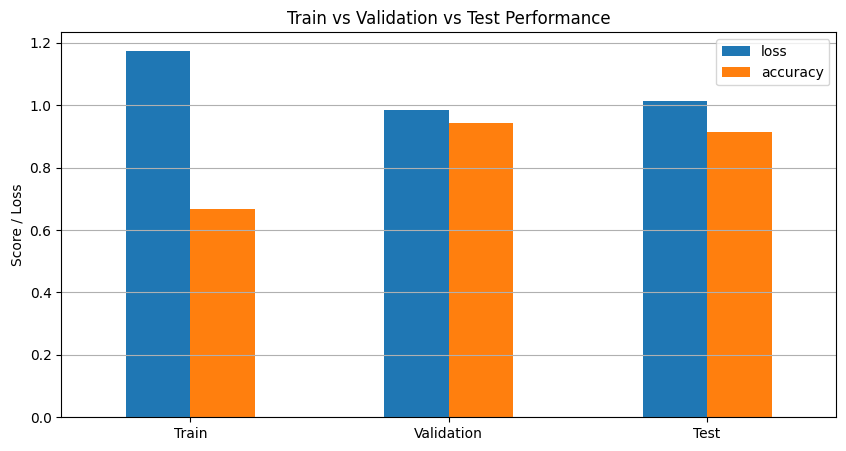

In [ ]:
# =========================================================
# PERFORMANCE BAR PLOT
# =========================================================
results_df.plot(kind="bar", figsize=(10, 5))

plt.title("Train vs Validation vs Test Performance")
plt.ylabel("Score / Loss")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

96/96 [==============================] - 1s 13ms/step


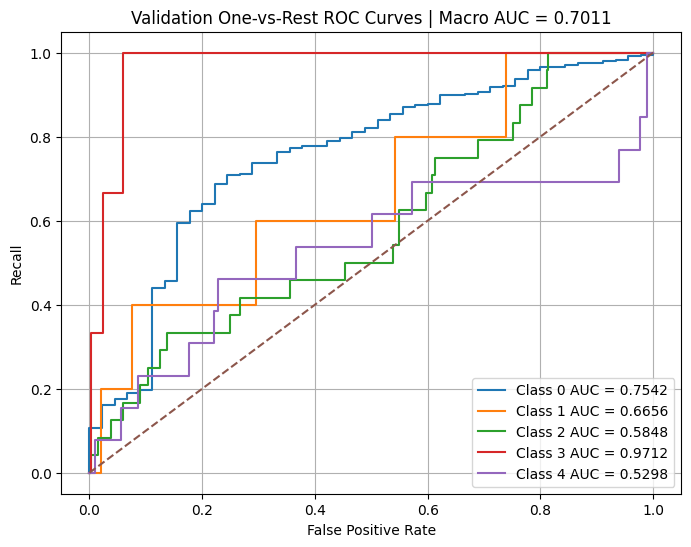

In [ ]:
# =========================================================
# VALIDATION ROC CURVE FOR DR_ICDR CLASSES
# =========================================================
y_val_array = np.asarray(y_val).astype(int)

val_probs = model.predict(val_ds)
y_val_bin = label_binarize(y_val_array, classes=list(range(NUM_CLASSES)))

plt.figure(figsize=(8, 6))

for class_idx in range(NUM_CLASSES):
    if len(np.unique(y_val_bin[:, class_idx])) < 2:
        print(f"Skipping ROC for Class {class_idx} because it has only one label value in validation data.")
        continue

    fpr, tpr, _ = roc_curve(y_val_bin[:, class_idx], val_probs[:, class_idx])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {class_idx} AUC = {roc_auc:.4f}")

try:
    macro_auc = roc_auc_score(
        y_val_array,
        val_probs,
        multi_class="ovr",
        average="macro"
    )
    title = f"Validation One-vs-Rest ROC Curves | Macro AUC = {macro_auc:.4f}"
except ValueError:
    title = "Validation One-vs-Rest ROC Curves"

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("Recall")
plt.title(title)
plt.legend()
plt.grid()
plt.show()
